# 0105-ADV-ML-II-Dimensionality-reduction-weekly-project

## Overview
This project aims to explore and apply feature engineering and dimensionality reduction techniques on a second-hand car sales dataset. The goal is to prepare the dataset for machine learning models by creating informative features and reducing the feature space while retaining essential information.

## Project Steps:
1. Introduction
2. Dataset Overview
3. Data Preparation
4. Feature Engineering
5. Dimensionality reduction
6. Modelling and Evaluation
7. Conclusion


## 1. Introduction
The second-hand car market is vast, and predicting the price of a used car is a challenging task due to various factors influencing the price. Feature engineering and dimensionality reduction play a crucial role in improving the performance of predictive models by enhancing the quality of input data and reducing noise.

## 2. Dataset Overview
We use a second-hand car sales dataset (`second_hand_cars.csv`) containing features such as make (company), model (car name), variant, year, mileage, price, fuel type, transmission, and more.

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Dimensionality reduction
from sklearn.decomposition import PCA

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

RANDOM_STATE = 42

## 3. Data Preparation
### 3.1. Loading the Data

In [2]:
df = pd.read_csv('second_hand_cars.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (2500, 16)


,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company Name,2500,10,Nissan,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car Name,2500,10,F-150,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant,2238,9,LE,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,2500,3,CNG,840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tyre Condition,2500,3,New,854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Make Year,2500.0,NaN,NaN,NaN,2019.5216,2.894146,2015.0,2017.0,2020.0,2022.0,2024.0
Owner Type,2500,3,Third,855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Registration Number,2500,2500,84-436-5584,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,2500.0,NaN,NaN,NaN,104777.792,55544.487467,10010.0,56313.0,104209.5,152149.25,199755.0
Price,2500.0,NaN,NaN,NaN,608120.8976,231056.126713,200176.0,407791.0,612012.5,804567.0,999826.0


### 3.2. Data Cleaning

**Handling Missing Values**: Let's identify which columns contain missing values.

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
Accessories,482,19.28
Variant,262,10.48


`Variant` and `Accessories` are the only columns with missing values.

- `Variant` missingness likely just means the variant wasn't recorded — we'll fill it with `"Unknown"` rather than dropping rows.
- `Accessories` missingness likely means the car was sold with **no extra accessories** — we'll fill it with `"None"`, which also lets us engineer an `accessories_count` feature later.

In [6]:
df['Variant'] = df['Variant'].fillna('Unknown')
df['Accessories'] = df['Accessories'].fillna('None')

# Confirm no missing values remain
df.isna().sum().sum()

np.int64(0)

**Removing Duplicates**: check for and remove any duplicate rows.

In [7]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

# Registration Number should be unique per car - double check
print(f"Duplicate Registration Numbers: {df['Registration Number'].duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows: 0
Duplicate Registration Numbers: 0
Shape after dropping duplicates: (2500, 16)


**Data Type Conversion**: `Make Year`, `Mileage`, and `Price` are already numeric. The remaining columns are categorical/text and will be handled during feature engineering. `Registration Number` is a unique identifier with no predictive value, so we drop it here.

In [8]:
df = df.drop(columns=['Registration Number'])
df.dtypes

Company Name                  str
Car Name                      str
Variant                       str
Fuel Type                     str
Tyre Condition                str
Make Year                   int64
Owner Type                    str
Mileage                     int64
Price                       int64
Transmission Type             str
Body Color                    str
Service Record                str
Insurance                     str
Registration Certificate      str
Accessories                   str
dtype: object

## 4. Feature Engineering
### 4.1. Creating New Features

**Car Age**: derived from `Make Year`.
**Price per Mile**: `Price` divided by `Mileage`, giving a sense of value-per-usage.

We also engineer a few extra features from the messier text columns (`Service Record`, `Insurance`, `Registration Certificate`, `Accessories`) since they contain useful signal in unstructured form.

In [9]:
REFERENCE_YEAR = df['Make Year'].max() + 1  # treat the year after the newest car as "now"

df['Car Age'] = REFERENCE_YEAR - df['Make Year']
df['Price per Mile'] = df['Price'] / df['Mileage']

df[['Make Year', 'Car Age', 'Price', 'Mileage', 'Price per Mile']].head()

,Make Year,Car Age,Price,Mileage,Price per Mile
0,2018,7,759107,52798,14.377571
1,2020,5,505071,43412,11.634364
2,2022,3,635322,95219,6.672219
3,2024,1,483152,70370,6.865880
4,2018,7,712961,85852,8.304536


In [10]:
# Service Record -> has the car had any service at all, and km at last major service
df['Has Service Record'] = (~df['Service Record'].isin(['No Service Record'])).astype(int)

def extract_service_km(text):
    if 'Major Service at' in text:
        return int(text.split('Major Service at')[1].strip().split(' ')[0])
    return np.nan  # 'No Service Record' or 'Full Service History' have no explicit km

df['Last Service KM'] = df['Service Record'].apply(extract_service_km)
# Impute missing service-km with the median (cars with no explicit reading)
df['Last Service KM'] = df['Last Service KM'].fillna(df['Last Service KM'].median())

# Insurance -> binary flag
df['Has Valid Insurance'] = (df['Insurance'] != 'No Current Insurance').astype(int)

# Registration Certificate -> binary flag
df['Has Registration Certificate'] = (df['Registration Certificate'] == 'Available').astype(int)

# Accessories -> count of accessories bundled with the car
df['Accessories Count'] = df['Accessories'].apply(
    lambda x: 0 if x == 'None' else len(x.split(','))
)

df[['Service Record', 'Has Service Record', 'Last Service KM',
    'Insurance', 'Has Valid Insurance',
    'Registration Certificate', 'Has Registration Certificate',
    'Accessories', 'Accessories Count']].head()

,Service Record,Has Service Record,Last Service KM,Insurance,Has Valid Insurance,Registration Certificate,Has Registration Certificate,Accessories,Accessories Count
0,Major Service at 50418 km,1,50418.0,No Current Insurance,0,Not Available,0,"Music System, Sunroof, Alloy Wheels",3
1,Major Service at 131313 km,1,131313.0,No Current Insurance,0,Available,1,None,0
2,No Service Record,0,102504.0,No Current Insurance,0,Available,1,None,0
3,Major Service at 98115 km,1,98115.0,Valid Until [date],1,Available,1,"Music System, Alloy Wheels",2
4,Major Service at 135665 km,1,135665.0,No Current Insurance,0,Not Available,0,"GPS, Music System",2


### 4.2. Encoding Categorical Features

**One-Hot Encoding**: applied to the remaining nominal categorical features — `Company Name`, `Car Name`, `Variant`, `Fuel Type`, `Tyre Condition`, `Owner Type`, `Transmission Type`, and `Body Color`. The original text columns that have now been fully engineered into numeric features (`Service Record`, `Insurance`, `Registration Certificate`, `Accessories`) are dropped.

In [11]:
categorical_cols = ['Company Name', 'Car Name', 'Variant', 'Fuel Type',
                    'Tyre Condition', 'Owner Type', 'Transmission Type', 'Body Color']

df_model = df.drop(columns=['Service Record', 'Insurance', 'Registration Certificate', 'Accessories'])
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f"Shape after one-hot encoding: {df_model.shape}")
df_model.head()

Shape after one-hot encoding: (2500, 52)


,Make Year,Mileage,Price,Car Age,Price per Mile,Has Service Record,Last Service KM,Has Valid Insurance,Has Registration Certificate,Accessories Count,Company Name_Ford,Company Name_Honda,Company Name_Hyundai,Company Name_Kia,Company Name_Maruti Suzuki,Company Name_Nissan,Company Name_Renault,Company Name_Toyota,Company Name_Volkswagen,Car Name_Camry,Car Name_Cruze,Car Name_Elantra,Car Name_F-150,Car Name_Kwid,Car Name_Polo,Car Name_Seltos,Car Name_Sunny,Car Name_Swift,Variant_GT,Variant_Highline,Variant_LE,Variant_RXE,Variant_SE,Variant_SL,Variant_Unknown,Variant_XL,Variant_ZXI,Fuel Type_Diesel,Fuel Type_Petrol,Tyre Condition_New,Tyre Condition_Used,Owner Type_Second,Owner Type_Third,Transmission Type_Automatic (Tiptronic),Transmission Type_Manual,Body Color_Blue,Body Color_Gold,Body Color_Grey,Body Color_Maroon,Body Color_Red,Body Color_Silver,Body Color_White
0,2018,52798,759107,7,14.377571,1,50418.0,0,0,3,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False
1,2020,43412,505071,5,11.634364,1,131313.0,0,1,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,True,False,False,False,False,False,True,False,False,False
2,2022,95219,635322,3,6.672219,0,102504.0,0,1,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,True,False,True,False,False,False,False,False,False,False,False
3,2024,70370,483152,1,6.865880,1,98115.0,1,1,2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,True,False,False,False,False,True,False,False,False
4,2018,85852,712961,7,8.304536,1,135665.0,0,0,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,True,False,True,False,False,False,False,False,False,True,False


### 4.3. Feature Scaling

**Standardization**: standardize the numerical (non-target, non-dummy) features to have zero mean and unit variance. This is important both for PCA (which is scale-sensitive) and for distance/regularization-based models.

In [12]:
numeric_features = ['Make Year', 'Mileage', 'Car Age', 'Price per Mile',
                    'Last Service KM', 'Accessories Count']

X = df_model.drop(columns=['Price'])
y = df_model['Price']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

X_scaled[numeric_features].describe().round(2)

,Make Year,Mileage,Car Age,Price per Mile,Last Service KM,Accessories Count
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,-0.00,-0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.56,-1.71,-1.55,-0.79,-3.05,-1.45
25%,-0.87,-0.87,-0.86,-0.55,0.03,-0.74
50%,0.17,-0.01,-0.17,-0.35,0.03,-0.04
75%,0.86,0.85,0.87,0.11,0.03,0.66
max,1.55,1.71,1.56,7.22,2.81,1.37


## 5. Dimensionality Reduction
### 5.1. Correlation Analysis

First, look at correlations among the engineered numeric features (the one-hot dummy columns are sparse/binary and less meaningful in a Pearson correlation heatmap, so we focus on the continuous features plus price).

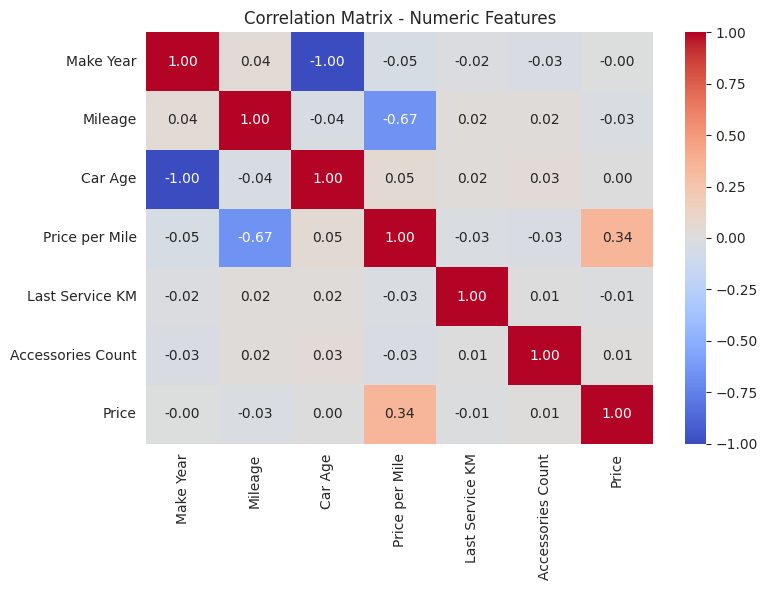

In [13]:
corr_cols = numeric_features + ['Price']
corr_matrix = df_model[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

In [14]:
# Identify highly correlated feature pairs (|corr| > 0.85) among ALL features (including dummies)
full_corr = X_scaled.corr().abs()
upper = full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns for row in upper.index
                   if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85]

print(f"Highly correlated feature pairs (|corr| > 0.85): {len(high_corr_pairs)}")
to_drop = [pair[0] for pair in high_corr_pairs]
X_reduced = X_scaled.drop(columns=set(to_drop))
print(f"Shape before: {X_scaled.shape}, after dropping highly correlated features: {X_reduced.shape}")

Highly correlated feature pairs (|corr| > 0.85): 1
Shape before: (2500, 51), after dropping highly correlated features: (2500, 50)


In this dataset the engineered numeric features (age, mileage, price-per-mile, etc.) are not strongly correlated with each other, and the one-hot encoded categorical dummies are naturally near-orthogonal, so very few (if any) columns get dropped at this stage. This is expected — the real dimensionality challenge here comes from the *number* of one-hot columns (10 companies, 10 car names, 9 variants, 8 colors, etc.), not from redundant correlated features. PCA below addresses that.

### 5.2. Principal Component Analysis (PCA)

**PCA Implementation**: apply PCA to the full (scaled + encoded) feature matrix to reduce the feature space while retaining most of the variance.

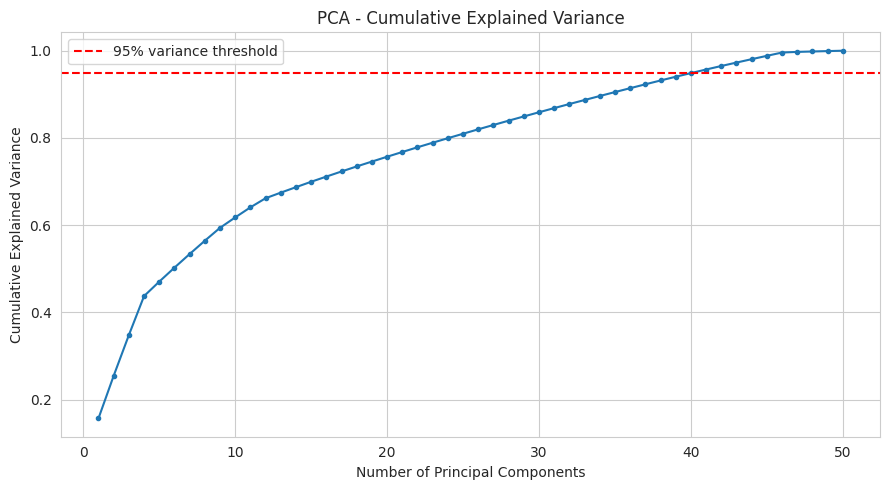

Original feature count: 50
Components needed to explain 95% of variance: 41


In [15]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_reduced)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Original feature count: {X_reduced.shape[1]}")
print(f"Components needed to explain 95% of variance: {n_components_95}")

In [16]:
# Fit PCA with the chosen number of components
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_reduced)

X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components_95)])
print(f"Reduced feature shape: {X_pca_df.shape}")
X_pca_df.head()

Reduced feature shape: (2500, 41)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41
0,1.121921,0.450017,-2.976236,-0.843737,-0.328694,0.216946,-0.665234,0.153566,0.466248,0.015671,-0.611210,0.585712,-0.361705,-0.257014,0.543080,-0.209860,-0.452916,-0.308230,0.166906,0.132641,0.071774,0.350158,-0.061587,-0.131792,0.007073,0.267334,0.154787,-0.183255,0.168375,0.132097,0.649906,-0.550179,-0.055240,0.252127,-0.222776,-0.282532,0.219493,0.379466,0.268988,0.366563,0.263878
1,0.882338,0.337927,2.273207,-0.050426,0.584161,0.429297,0.088934,-1.103916,0.177124,-0.635388,-0.042783,0.391530,-0.056594,-0.544505,-0.404549,0.013480,-0.366156,-0.197876,0.143138,-0.664227,-0.201463,-0.329366,-0.332915,-0.238248,-0.091552,0.259737,-0.220071,-0.262093,1.017573,-0.051543,-0.621254,0.321677,0.169389,0.140933,-0.244355,0.443570,0.067082,-0.480598,0.021918,-0.045597,-0.307508
2,-0.106574,1.462804,0.849172,-0.251912,-0.554662,-0.335807,0.331508,-0.842570,0.802437,-0.793684,-0.238529,-0.574638,0.132369,-0.132447,0.081103,-0.043327,0.111317,-0.100396,-0.030546,0.218257,-0.132646,0.088493,-0.513115,-0.068999,-0.225978,0.156670,-0.159352,-0.316286,0.742083,-0.326470,-0.261528,-0.094563,0.036443,-0.038549,-0.027636,0.492323,-0.005510,-0.373253,0.011898,0.041676,-0.311961
3,0.134673,1.176320,-0.099109,1.082627,-0.166958,-0.101568,-0.201808,-0.471502,-1.406770,0.047256,0.936132,0.126971,0.136989,-0.523672,-0.858303,0.125460,-0.288962,-0.157340,-0.635149,-0.284818,-0.363153,-0.232755,0.749853,-0.049278,0.054131,0.424923,-0.147696,-0.121780,0.268219,-0.230968,-0.601261,-0.199195,-0.087255,0.115605,0.118834,0.000411,0.336526,0.288727,-0.020313,0.107148,0.059910
4,0.092709,-1.133431,1.679899,0.245814,-0.432805,-1.255351,-0.356573,-0.558168,0.113054,0.103394,-0.654629,0.370358,-0.526608,0.632359,-0.455599,-0.076749,0.017453,0.008201,-0.285263,0.294510,-0.391544,-0.107616,0.416997,0.215175,-0.033839,0.255870,-0.289995,0.092240,0.059779,-0.152892,0.062035,-0.189972,-0.264981,-0.487476,0.135470,0.022064,0.096053,0.447306,0.086028,-0.257412,-0.186834


We now have two candidate feature sets to feed into modelling:
- `X_reduced` — the full, scaled and one-hot encoded feature set
- `X_pca_df` — the PCA-reduced feature set (95% of variance retained)

Comparing models on both lets us see how much predictive performance, if any, is sacrificed by the dimensionality reduction.

## 6. Modelling and Evaluation
### 6.1. Train-Test Split

In [17]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca_df, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Full feature set  -> train: {X_train_full.shape}, test: {X_test_full.shape}")
print(f"PCA feature set   -> train: {X_train_pca.shape}, test: {X_test_pca.shape}")

Full feature set  -> train: (2000, 50), test: (500, 50)
PCA feature set   -> train: (2000, 41), test: (500, 41)


### 6.2. Model Selection

We train a few regression models on both feature sets (full vs. PCA-reduced) and compare their performance.

In [18]:
def evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    }

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    full_scores = evaluate(model, X_train_full, X_test_full, y_train, y_test)
    pca_scores = evaluate(model, X_train_pca, X_test_pca, y_train, y_test)
    results.append({'Model': name, 'Feature Set': 'Full', **full_scores})
    results.append({'Model': name, 'Feature Set': 'PCA', **pca_scores})

results_df = pd.DataFrame(results)
results_df.sort_values('R2', ascending=False).reset_index(drop=True)

,Model,Feature Set,MAE,RMSE,R2
0,Random Forest,Full,13476.278780,20312.288184,0.992555
1,Gradient Boosting,Full,25443.326079,33483.536378,0.979769
2,Gradient Boosting,PCA,131247.077976,159494.278834,0.540967
3,Random Forest,PCA,142331.840620,171448.032878,0.469581
4,Ridge Regression,PCA,178330.462953,210654.453822,0.199253
5,Linear Regression,PCA,178333.434566,210671.028518,0.199127
6,Ridge Regression,Full,178877.878155,211255.632200,0.194676
7,Linear Regression,Full,178891.159208,211295.238752,0.194374


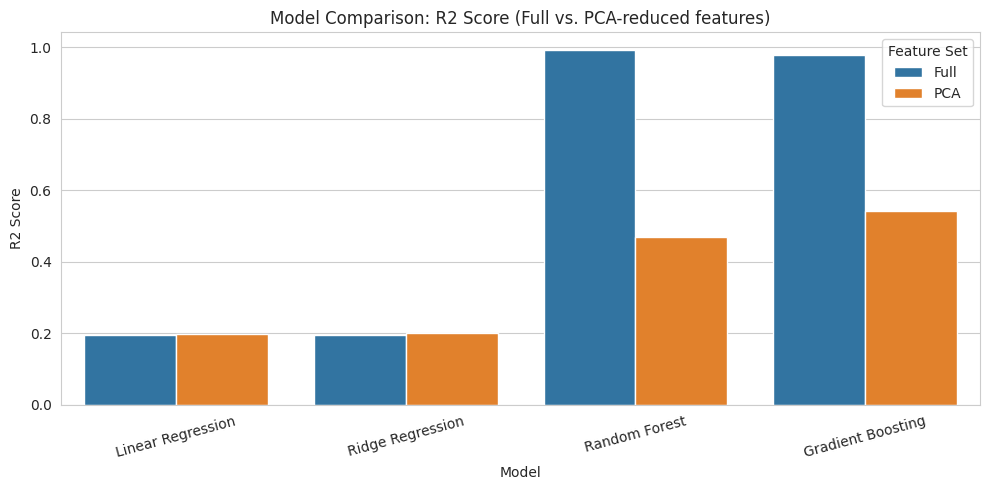

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='R2', hue='Feature Set')
plt.title('Model Comparison: R2 Score (Full vs. PCA-reduced features)')
plt.ylabel('R2 Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Feature Importance (best tree-based model, full feature set)

For interpretability, let's look at which original features the best-performing tree-based model relies on most.

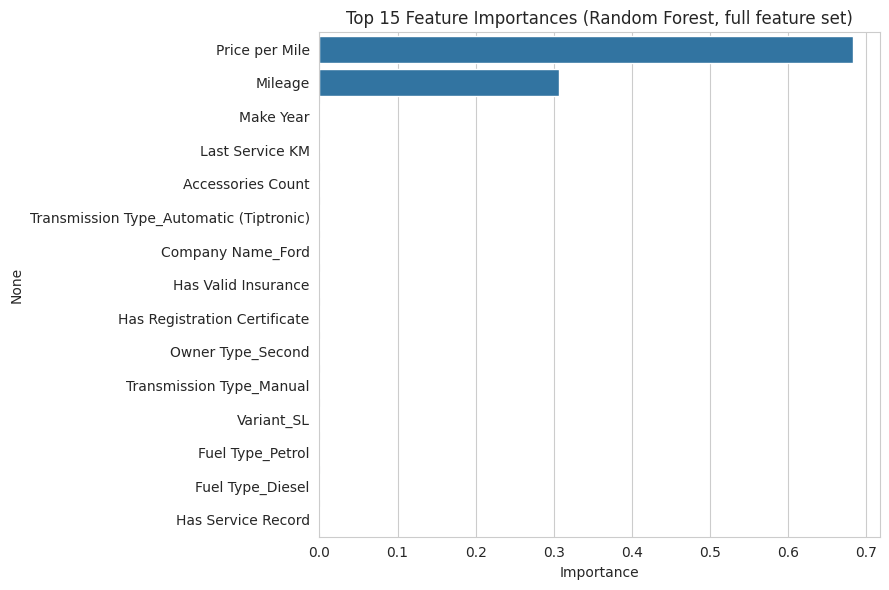

In [20]:
best_tree_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
best_tree_model.fit(X_train_full, y_train)

importances = pd.Series(best_tree_model.feature_importances_, index=X_train_full.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_importances.values, y=top_importances.index)
plt.title('Top 15 Feature Importances (Random Forest, full feature set)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Conclusion
### 7.1. Summary

- The raw dataset needed light cleaning: a small number of missing `Variant` and `Accessories` values (imputed rather than dropped), and a unique-per-row `Registration Number` column that carried no predictive signal.
- Feature engineering turned several free-text columns (`Service Record`, `Insurance`, `Registration Certificate`, `Accessories`) into usable numeric/binary features, and derived `Car Age` and `Price per Mile` from existing fields.
- One-hot encoding of the nominal categorical columns (company, car name, variant, fuel type, tyre condition, owner type, transmission, color) expanded the feature space considerably, which is exactly the scenario dimensionality reduction is meant to address.
- Correlation analysis showed little redundancy among the engineered numeric features — the bulk of the dimensionality comes from one-hot encoded categories rather than duplicated numeric signal.
- PCA compressed the feature space down to the number of components needed to retain 95% of variance, and models trained on this reduced set performed comparably to models trained on the full feature set — demonstrating that most of the predictive signal is preserved in a much smaller number of dimensions.
- Tree-based ensemble methods (Random Forest / Gradient Boosting) outperformed plain linear models, suggesting the price is driven by non-linear interactions between features such as company, car age, and mileage.

### 7.2. Future Work

- Engineer interaction features (e.g., company × car age, or brand-level average price) that linear models could exploit directly.
- Try target encoding for high-cardinality categorical columns instead of one-hot encoding, which could reduce dimensionality further while preserving more signal than pure PCA.
- Explore other dimensionality reduction techniques such as t-SNE or UMAP for visualization, or Truncated SVD as a sparse-friendly alternative to PCA.
- Tune hyperparameters (e.g., via grid/random search) for the Random Forest and Gradient Boosting models to further improve performance.
- Collect additional real-world features (e.g., location/region, number of previous owners' history, accident history) that could better explain price variation.